# Income

GDP per capita at purchasing power parity from **[Kummu, Kosonen & Masoumzadeh Sayyar 2025 — Downscaled gridded global dataset for GDP per capita PPP over 1990–2022](https://www.nature.com/articles/s41597-025-04487-x)** (Aalto University, [Zenodo record 16741980](https://zenodo.org/records/16741980)). The 30 arc-min (0.5°) multiband GeoTIFF has one band per year 1990–2022 in 2017 international USD per person. It downscales national statistics onto admin-2 boundaries (~43 500 units, subnational data for 89 countries), so values are jurisdiction-flat inside admin units rather than truly gridded — matching `DATASETS.md`'s caveat that no true global gridded income source exists (🔴 Tier C).

We take the latest year (2022, band 33), snap the raster onto the atlas grid, `log10`-transform, fill uncovered land cells with the geometric mean of each country's covered cells (via the Natural Earth 50m admin_0 polygons already cached by `19_climate_vulnerability`), and mask ocean via `is_land` from `grid.nc`. The country-mean fill matters because the source only rasterizes admin-2 polygons — coastlines and small territories often miss the atlas grid; falling back to the country geometric mean is a natural proxy since the underlying data is national statistics anyway. The log transform is essential because per-capita income spans ~2.5 orders of magnitude between the poorest (~$500) and richest (~$130 000) admin-2 units — a linear min-max at the scoring stage would collapse everything below the top decile. Higher income = better, so no sign inversion. Chose the 30 arcmin file over the 5 arcmin one because they encode the same admin-2-flat information and the 30 arcmin version already aligns to the atlas grid (4.8 MB vs 121 MB download).

In [1]:
import numpy as np
import rasterio
import xarray as xr

from common import RAW_DIR, download, load_grid, plot_map, save_variable

VARIABLE = 'income'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

YEAR = 2022  # latest year in the Kummu et al. 2025 release
BASE_YEAR = 1990  # band 1 = 1990, band N = 1989 + N

## 1. Fetch raw data

Single 30 arc-min multiband GeoTIFF from Zenodo (~5 MB). Cached under `variable_raw`; the download only runs once.

In [2]:
URL = 'https://zenodo.org/records/16741980/files/rast_adm2_gdp_perCapita_1990_2022_30arcmin.tif?download=1'
tif_path = variable_raw / 'rast_adm2_gdp_perCapita_1990_2022_30arcmin.tif'

if not tif_path.exists():
    print(f'downloading {URL}')
    await download(URL, tif_path)

print(f'{tif_path.name}: {tif_path.stat().st_size / 1024**2:.1f} MB')

rast_adm2_gdp_perCapita_1990_2022_30arcmin.tif: 4.6 MB


## 2. Read the latest-year band and snap to the atlas grid

Bands are 1-indexed and start at 1990, so `band = YEAR - BASE_YEAR + 1`. The source affine transform has negative pixel height (rows go north→south), giving a descending latitude coord — `xarray.interp` handles either direction as long as coords are monotonic. Nearest-neighbour resampling is appropriate because the underlying data is admin-2-flat: any smoothing across boundaries would blur real jurisdictional discontinuities into the score.

Non-positive or nodata pixels become `NaN`; the next step fills these gaps where the cell falls inside a country polygon so they neither log-explode nor drop out of the atlas.

In [3]:
grid = load_grid()

with rasterio.open(tif_path) as src:
    assert src.crs.to_epsg() == 4326, f'expected EPSG:4326, got {src.crs}'
    band = YEAR - BASE_YEAR + 1
    assert 1 <= band <= src.count, f'band {band} outside available 1..{src.count}'
    raw = src.read(band).astype('float64')
    nodata = src.nodata
    src_lon = src.transform.c + src.transform.a * (np.arange(src.width) + 0.5)
    src_lat = src.transform.f + src.transform.e * (np.arange(src.height) + 0.5)

mask = np.isfinite(raw) & (raw > 0)
if nodata is not None:
    mask &= raw != nodata
raw = np.where(mask, raw, np.nan)

gdp_pc = xr.DataArray(
    raw,
    coords={'lat': src_lat, 'lon': src_lon},
    dims=('lat', 'lon'),
    name='gdp_per_capita_ppp',
).interp(lat=grid.lat, lon=grid.lon, method='nearest')

finite = gdp_pc.where(np.isfinite(gdp_pc))
print(f'{int(finite.notnull().sum())} of {gdp_pc.size} cells covered in {YEAR} '
      f'(range ${float(finite.min()):,.0f} – ${float(finite.max()):,.0f})')

/var/folders/hq/d3n2t3r135gfw07crm1cqnrh0000gn/T/ipykernel_73186/553135181.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  raw = src.read(band).astype('float64')


51357 of 259200 cells covered in 2022 (range $11 – $738,197)


## 3. Fill uncovered land cells with a country geometric mean

The Kummu raster leaves gaps where a grid cell centre falls outside every admin-2 polygon — mostly small islands, coastlines, and disputed borders. For each such cell we substitute the geometric mean of that country's covered cells (i.e. the mean of `log10(GDP)` per country). Log-space averaging matches how the atlas uses log-income downstream and is less pulled by a country's richest admin-2 unit than an arithmetic mean would be. Countries with zero coverage in the source (rare — mostly disputed or ISO3-less territories) remain `NaN` and are handled by `weighted_score` at the top-level scoring stage. Country polygons come from the Natural Earth 50m admin_0 shapefile already cached by `19_climate_vulnerability` / `34_human_freedom` / `35_corruption`.

In [4]:
import geopandas as gpd
import httpx
import pandas as pd
import regionmask

ne_countries_zip = RAW_DIR / 'climate_vulnerability' / 'ne_50m_admin_0_countries.zip'
if not ne_countries_zip.exists():
    NE_URL = 'https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip'
    print(f'downloading {NE_URL}')
    r = httpx.get(NE_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=180, follow_redirects=True)
    r.raise_for_status()
    ne_countries_zip.parent.mkdir(parents=True, exist_ok=True)
    ne_countries_zip.write_bytes(r.content)

countries = (
    gpd.read_file(f'zip://{ne_countries_zip}')
    .to_crs('EPSG:4326')
    [['ISO_A3_EH', 'geometry']]
    .rename(columns={'ISO_A3_EH': 'ISO3'})
    .reset_index(drop=True)
)

# Rasterise polygon indices onto the atlas grid; multi-polygon countries get one index per
# polygon, so we aggregate by ISO3 (not polygon) below.
regions = regionmask.from_geopandas(countries, overlap=False)
poly_idx = regions.mask(grid.lon, grid.lat).values.ravel()

log_gdp = np.log10(gdp_pc)

inside = np.isfinite(poly_idx)
iso_flat = np.full(poly_idx.size, None, dtype=object)
iso_flat[inside] = countries['ISO3'].to_numpy()[poly_idx[inside].astype(int)]

country_means = (
    pd.DataFrame({'ISO3': iso_flat, 'log_gdp': log_gdp.values.ravel()})
    .dropna()
    .groupby('ISO3')['log_gdp']
    .mean()
)

fill_flat = pd.Series(iso_flat).map(country_means).to_numpy(dtype='float64')
country_fill = xr.DataArray(fill_flat.reshape(log_gdp.shape), coords=log_gdp.coords, dims=log_gdp.dims)

before = int(log_gdp.notnull().sum())
log_gdp = log_gdp.fillna(country_fill)
after = int(log_gdp.notnull().sum())
land = int((grid.is_land == 1).sum())
print(f'filled {after - before:,} cells with country geometric means; '
      f'{after:,} of {land:,} land cells now covered ({100 * after / land:.1f}%)')

filled 15,358 cells with country geometric means; 66,715 of 85,959 land cells now covered (77.6%)


## 4. Mask ocean and tag

Ocean cells are dropped via `is_land`; the log-transform and country-mean fill are already applied.

In [5]:
values = (
    log_gdp
    .astype('float32')
    .rename(VARIABLE)
    .where(grid.is_land == 1)
)
values.attrs['units'] = 'log₁₀(2017 international USD per person)'
values.attrs['source'] = (
    f'Kummu et al. 2025 rast_adm2_gdp_perCapita_1990_2022_30arcmin.tif band '
    f'{YEAR - BASE_YEAR + 1}; gaps filled with country geometric mean from Natural Earth polygons'
)
values.attrs['source_year'] = YEAR
values

<xarray.DataArray 'income' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    units:        log₁₀(2017 international USD per person)
    source:       Kummu et al. 2025 rast_adm2_gdp_perCapita_1990_2022_30arcmi...
    source_year:  2022

## 5. Plot

<Axes: title={'center': 'income'}, xlabel='longitude', ylabel='latitude'>

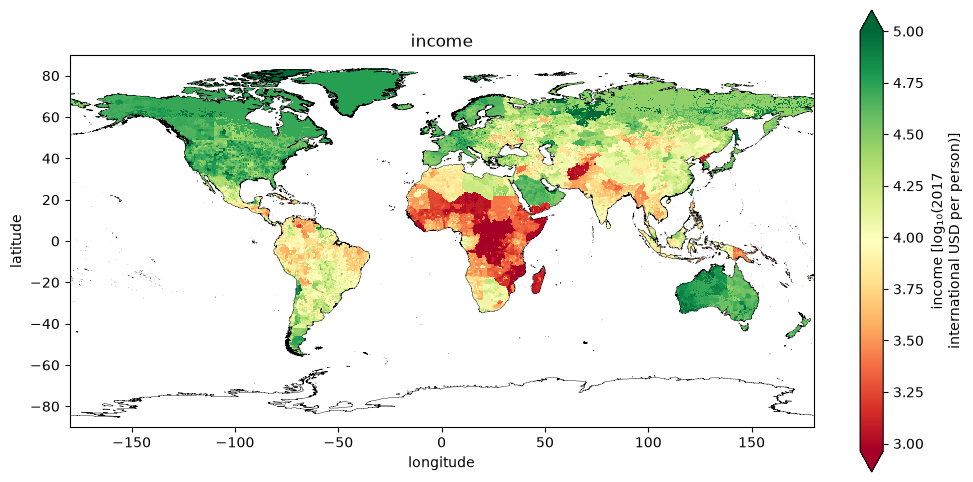

In [6]:
plot_map(values, cmap='RdYlGn', robust=True)

## 6. Save

In [7]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/income.nc
